# TY and BTC Final Story From Confirmed C++ Results

This notebook is the final presentation layer for the project. It does **not** rerun the backtests. Instead, it reads the confirmed C++ output files and the exported Python diagnostics, then rebuilds the report in one place with clean, Columbia-style visuals.

**What this notebook answers**

- What inefficiency do we see in `TY` and `BTC` from the variance-ratio and push-response tests?
- Why is a trend-following system still appropriate for both markets?
- What are the headline out-of-sample results for `Channel WithDDControl`?
- How do the full-sample and reference-split results compare to the walk-forward OOS experiment?
- How sensitive are the results to transaction costs?

**Confirmed result sources**

- `results_cpp_official_quick/`
- `results_cpp_official_quick_report/`
- `results_diagnostics_story/`
- `results_cost_sensitivity_fixed/`

The transaction-cost assumptions used here come from the official `TF Data` reference:

- `TY` round-turn slippage: `$18.625`
- `BTC` round-turn slippage: `$25.00`


In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import Markdown, display

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "mafn_engine").exists() and (candidate / "results_cpp_official_quick").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from notebook cwd.")


ROOT = find_project_root()
CPP_RESULTS = ROOT / "results_cpp_official_quick"
CPP_REPORT = ROOT / "results_cpp_official_quick_report"
DIAG_RESULTS = ROOT / "results_diagnostics_story"
COST_RESULTS = ROOT / "results_cost_sensitivity_fixed"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 140,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#0F2D52",
        "axes.titlecolor": "#0F2D52",
        "xtick.color": "#23406A",
        "ytick.color": "#23406A",
        "grid.color": "#D4E2F1",
        "grid.alpha": 0.9,
        "axes.facecolor": "#FAFCFE",
        "savefig.facecolor": "white",
        "font.size": 11,
    }
)

COLUMBIA_DARK = "#0F2D52"
COLUMBIA_BLUE = "#6BA4D9"
COLUMBIA_LIGHT = "#B9D9EB"
COLUMBIA_GOLD = "#C9A227"
COLUMBIA_RED = "#B04A5A"


def money(x: float) -> str:
    return f"${x:,.0f}"


def pct(x: float) -> str:
    return f"{100*x:.1f}%"


def ratio(x: float) -> str:
    return f"{x:.3f}"


display(Markdown(f"**Project root:** `{ROOT}`"))


**Project root:** `/Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project`

In [2]:
DATE_FMT = "%m/%d/%Y %H:%M"


def load_market_bundle(market: str) -> dict[str, pd.DataFrame]:
    base = CPP_RESULTS / market
    report = CPP_REPORT / market
    diag = DIAG_RESULTS
    bundle = {
        "oos_returns": pd.read_csv(base / f"{market}_tf_oos_returns.csv", parse_dates=["DateTime"], date_format=DATE_FMT),
        "full_returns": pd.read_csv(base / f"{market}_tf_fullsample_returns.csv", parse_dates=["DateTime"], date_format=DATE_FMT),
        "reference_series": pd.read_csv(base / f"{market}_tf_reference_series.csv", parse_dates=["DateTime"], date_format=DATE_FMT),
        "periods": pd.read_csv(base / f"{market}_tf_walkforward_periods.csv", parse_dates=["ISStart", "ISEnd", "OOSStart", "OOSEnd"], date_format=DATE_FMT),
        "derived": pd.read_csv(report / f"{market}_walkforward_derived_stats.csv"),
        "trade_stats": pd.read_csv(report / f"{market}_walkforward_trade_stats.csv"),
        "vr": pd.read_csv(diag / f"{market}_vr_curve.csv"),
        "short_pr": pd.read_csv(diag / f"{market}_short_pr.csv"),
        "reference_pr": pd.read_csv(diag / f"{market}_reference_pr.csv"),
        "showcase_pr": pd.read_csv(diag / f"{market}_showcase_pr.csv"),
    }
    return bundle


summary = pd.read_csv(CPP_RESULTS / "tf_backtest_summary.csv")
overview = pd.read_csv(CPP_REPORT / "cpp_backtest_report_overview.csv")
cost_sensitivity = pd.read_csv(COST_RESULTS / "cost_sensitivity_summary.csv")
pr_metadata = pd.read_csv(DIAG_RESULTS / "push_response_metadata.csv")
markets = {ticker: load_market_bundle(ticker) for ticker in ["TY", "BTC"]}

summary["Market"] = summary["Market"].astype(str).str.strip()
summary["RunType"] = summary["RunType"].astype(str).str.strip()
overview["Market"] = overview["Market"].astype(str).str.strip()
overview["RunKind"] = overview["RunKind"].astype(str).str.strip()
pr_metadata["Ticker"] = pr_metadata["Ticker"].astype(str).str.strip()
pr_metadata["Kind"] = pr_metadata["Kind"].astype(str).str.strip()

required = [
    CPP_RESULTS / "tf_backtest_summary.csv",
    CPP_REPORT / "cpp_backtest_report_overview.csv",
    DIAG_RESULTS / "two_market_diagnostics_reference.png",
    COST_RESULTS / "cost_sensitivity_summary.csv",
]

missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required confirmed outputs:\n" + "\n".join(missing))

display(Markdown("### Confirmed Inputs Loaded"))
display(pd.DataFrame({"Path": [str(path) for path in required]}))


### Confirmed Inputs Loaded

,Path
0,/Users/nigelli/Desktop/Columbia MAFN/26Spring/...
1,/Users/nigelli/Desktop/Columbia MAFN/26Spring/...
2,/Users/nigelli/Desktop/Columbia MAFN/26Spring/...
3,/Users/nigelli/Desktop/Columbia MAFN/26Spring/...


## 1. Headline Assignment Answers

The project asked us to:

1. diagnose the two time series with variance-ratio and push-response tests,
2. infer the range of time-scales where inefficiency appears,
3. implement the `Channel WithDDControl` trend-following system,
4. run a 4-year in-sample / next-quarter out-of-sample rolling walk-forward,
5. compare OOS behavior to longer-run benchmark configurations.

The next cells summarize those answers directly from the confirmed outputs.


In [3]:
walkforward = summary.loc[summary["RunType"] == "walkforward_oos"].copy()
fullsample = summary.loc[summary["RunType"] == "full_sample"].copy()
reference_oos = summary.loc[summary["RunType"] == "reference_out_of_sample"].copy()


def metadata_row(ticker: str, kind: str) -> pd.Series:
    row = pr_metadata.loc[(pr_metadata["Ticker"] == ticker) & (pr_metadata["Kind"] == kind)]
    return row.iloc[0]


def vr_story_row(ticker: str, reference_q: int) -> dict[str, object]:
    vr = markets[ticker]["vr"].sort_values("q").reset_index(drop=True)
    trough = vr.loc[vr["VR"].idxmin()]
    nearest_ref = vr.iloc[(vr["q"] - reference_q).abs().argsort()[:1]].iloc[0]
    final_pt = vr.iloc[-1]
    return {
        "Market": ticker,
        "VR trough q": int(trough["q"]),
        "VR trough": float(trough["VR"]),
        "VR at reference q": float(nearest_ref["VR"]),
        "VR at max q": float(final_pt["VR"]),
        "Narrative": (
            "Short-horizon MR / mixed, then longer-horizon recovery toward TF"
            if ticker == "TY"
            else "Mixed short horizon, clearer TF only at longer horizons"
        ),
    }


story_rows = []
for ticker, ref_q in [("TY", 1440), ("BTC", 1152)]:
    ref_meta = metadata_row(ticker, "reference")
    show_meta = metadata_row(ticker, "showcase")
    wf = walkforward.loc[walkforward["Market"] == ticker].iloc[0]
    story_rows.append(
        {
            "Market": ticker,
            "Short-Horizon PR": f"rho={metadata_row(ticker, 'short')['Rho']:+.3f}",
            "Reference PR": f"rho={ref_meta['Rho']:+.3f}",
            "Showcase PR": f"rho={show_meta['Rho']:+.3f}",
            "Reference Scale": str(ref_meta["TauScale"]),
            "Showcase Scale": str(show_meta["TauScale"]),
            "Walk-Forward L": int(wf["L"]),
            "Walk-Forward S": float(wf["S"]),
            "OOS Net Profit": wf["NetProfit"],
            "OOS Net RoA": wf["NetRoA"],
            "OOS Net Sharpe": markets[ticker]["derived"]["NetSharpe"].iloc[0],
        }
    )

story_df = pd.DataFrame(story_rows)
vr_story_df = pd.DataFrame([vr_story_row("TY", 1440), vr_story_row("BTC", 1152)])

display(Markdown("### Final Story Snapshot"))
display(
    story_df.style.format(
        {
            "OOS Net Profit": money,
            "OOS Net RoA": ratio,
            "OOS Net Sharpe": ratio,
        }
    )
)
display(Markdown("### Variance-Ratio Story Summary"))
display(vr_story_df.style.format({"VR trough": "{:.3f}", "VR at reference q": "{:.3f}", "VR at max q": "{:.3f}"}))


### Final Story Snapshot

,Market,Short-Horizon PR,Reference PR,Showcase PR,Reference Scale,Showcase Scale,Walk-Forward L,Walk-Forward S,OOS Net Profit,OOS Net RoA,OOS Net Sharpe
0,TY,rho=+0.082,rho=+0.591,rho=+0.591,18.0sess,18.0sess,1440,0.010000,"$47,619",1.575,0.228
1,BTC,rho=-0.382,rho=-0.464,rho=+0.673,4.0d,12.0d,288,0.010000,"$490,398",3.543,2.980


### Variance-Ratio Story Summary

,Market,VR trough q,VR trough,VR at reference q,VR at max q,Narrative
0,TY,800,0.888,0.911,0.949,"Short-horizon MR / mixed, then longer-horizon recovery toward TF"
1,BTC,2474,0.817,0.835,0.889,"Mixed short horizon, clearer TF only at longer horizons"


## 2. Time-Series Diagnostics

The diagnostics figure is the core narrative:

- `TY` does **not** need `VR(q)` to cross above `1` at the monthly horizon.
- The important point is that `TY` looks more mean-reverting or weak at short horizons, then the variance ratio bends upward as `q` increases and the push-response becomes more trend-like around the longer horizon.
- `BTC` is more volatile and can still look noisy at short horizons, but the longer-horizon push-response becomes clearly trend-following.


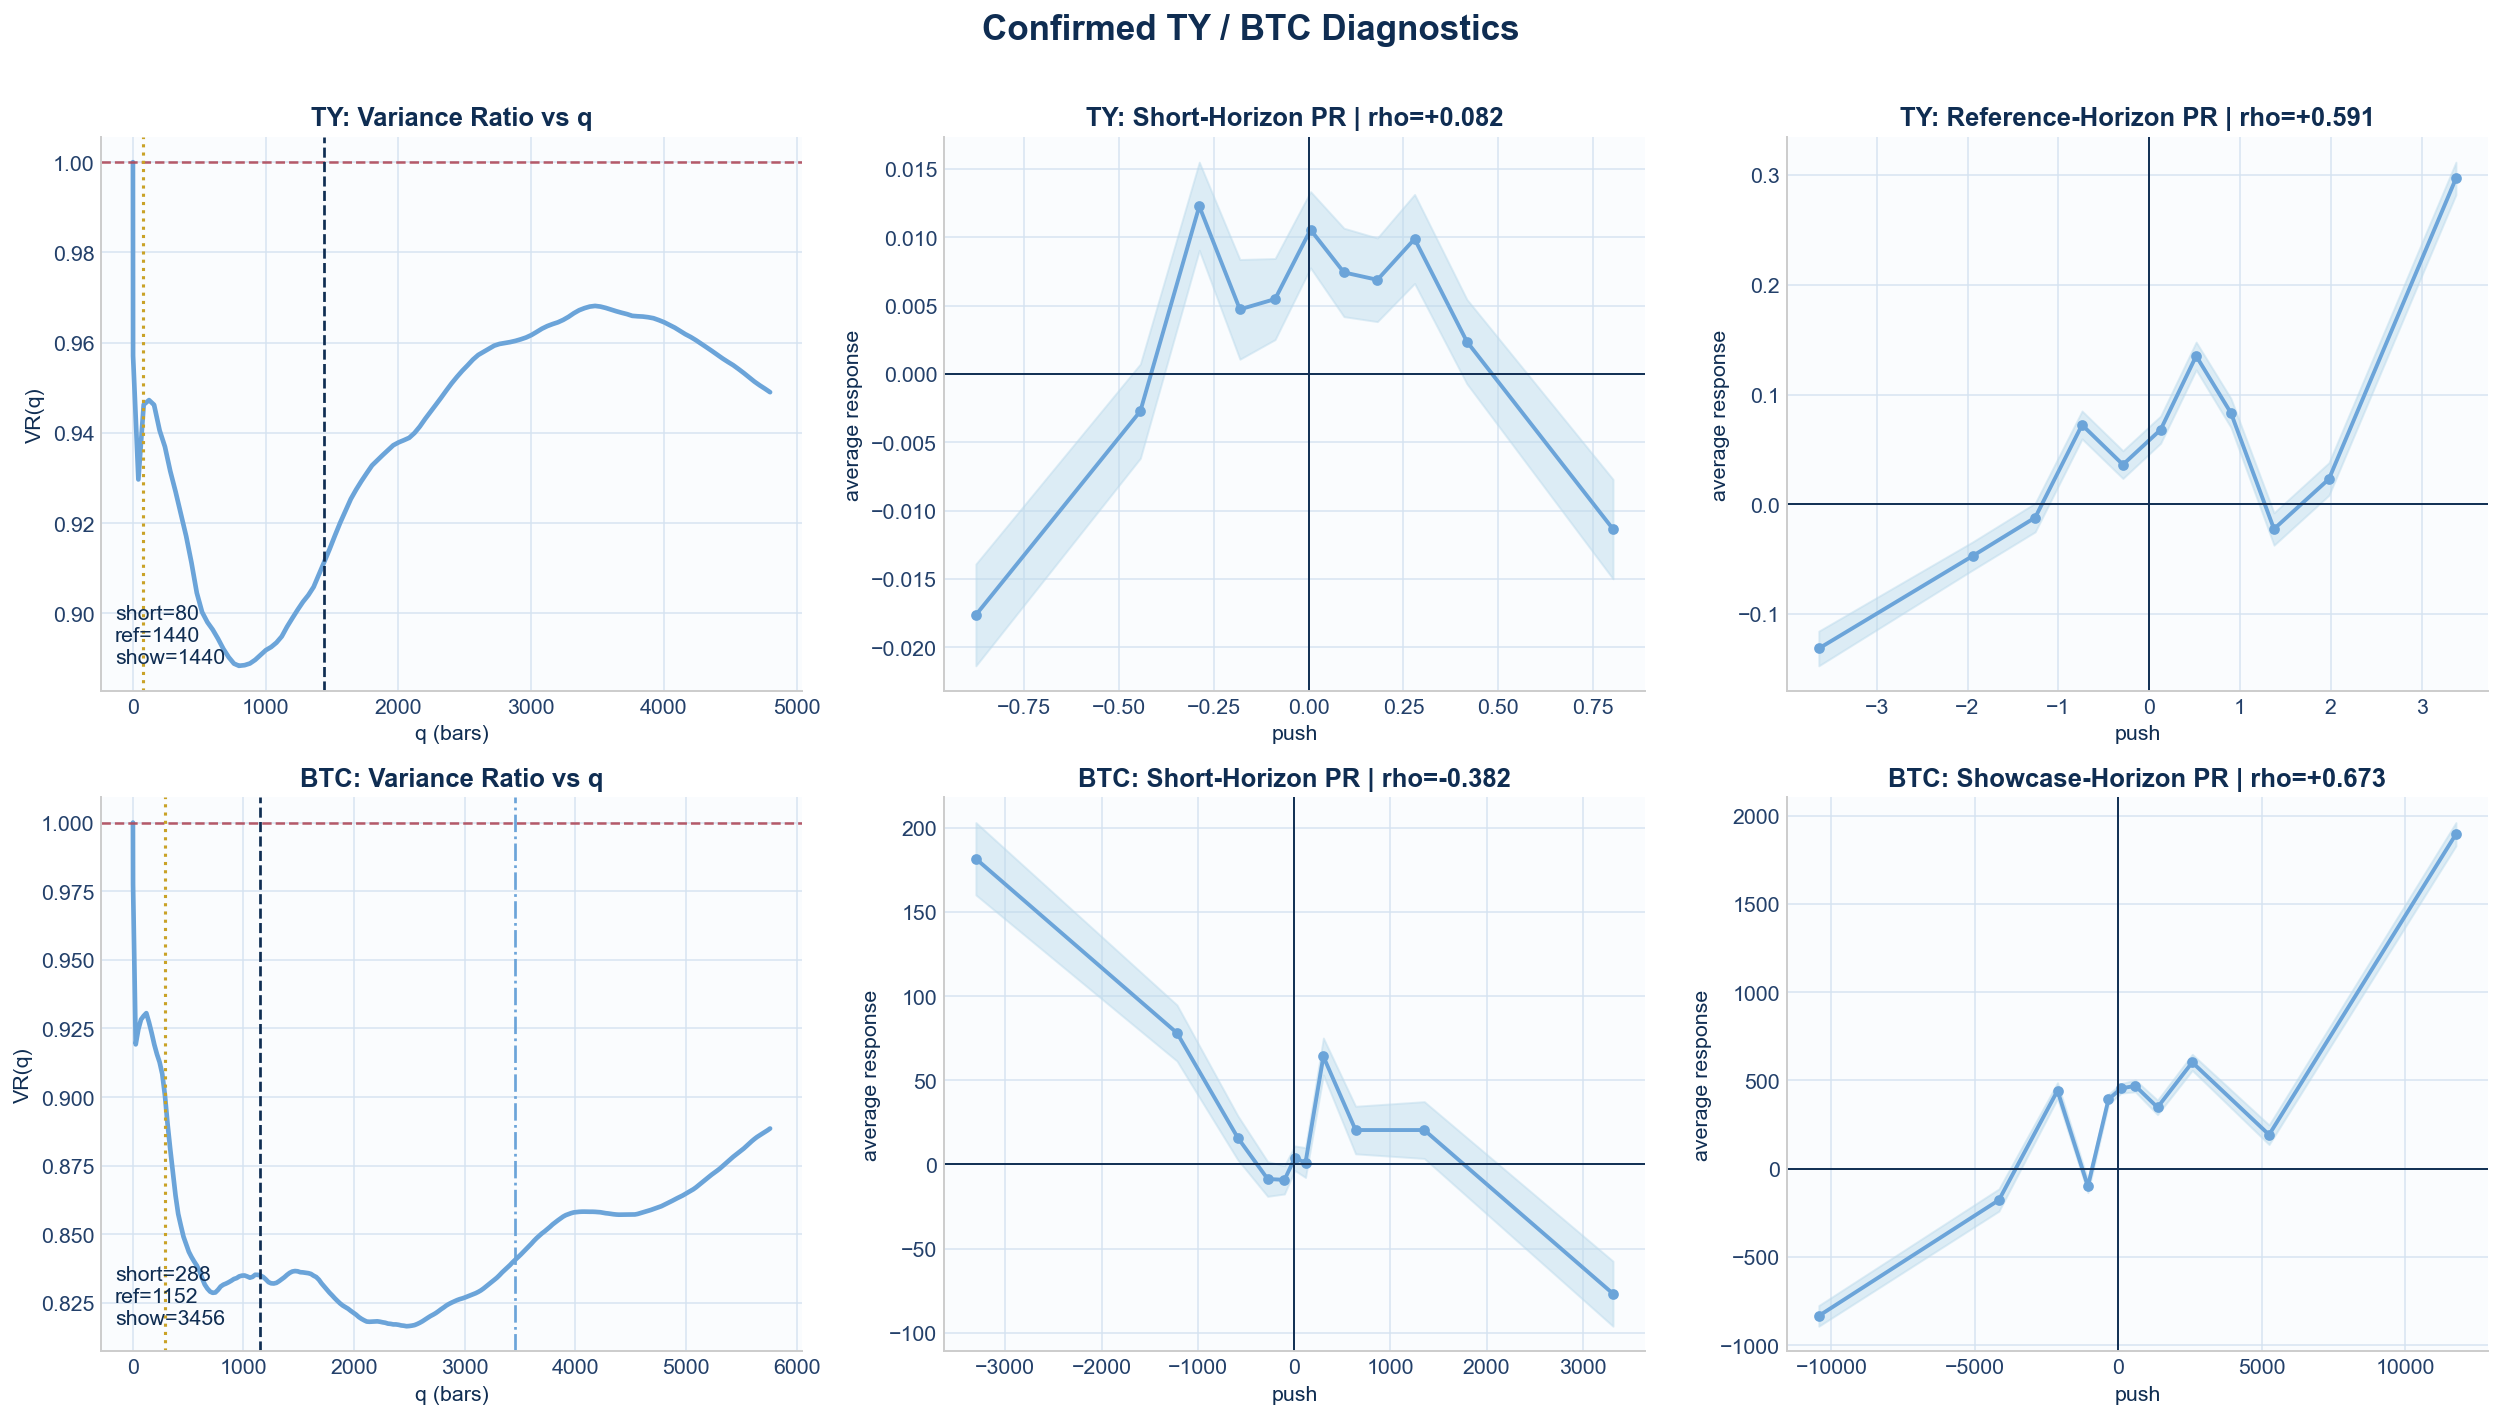

In [4]:
def plot_vr(ax, ticker: str, short_q: int, ref_q: int, showcase_q: int) -> None:
    vr = markets[ticker]["vr"].sort_values("q")
    ax.plot(vr["q"], vr["VR"], color=COLUMBIA_BLUE, linewidth=2.4)
    ax.axhline(1.0, color=COLUMBIA_RED, linestyle="--", linewidth=1.3, alpha=0.9)
    ax.axvline(short_q, color=COLUMBIA_GOLD, linestyle=":", linewidth=1.6)
    ax.axvline(ref_q, color=COLUMBIA_DARK, linestyle="--", linewidth=1.4)
    if showcase_q != ref_q:
        ax.axvline(showcase_q, color=COLUMBIA_BLUE, linestyle="-.", linewidth=1.4)
    ax.set_title(f"{ticker}: Variance Ratio vs q")
    ax.set_xlabel("q (bars)")
    ax.set_ylabel("VR(q)")
    ax.text(0.02, 0.05, f"short={short_q}\nref={ref_q}\nshow={showcase_q}", transform=ax.transAxes, color=COLUMBIA_DARK)


def plot_pr(ax, df: pd.DataFrame, title: str, rho: float) -> None:
    ax.plot(df["bin_centre"], df["bin_mean"], color=COLUMBIA_BLUE, marker="o", linewidth=2.0, markersize=4.5)
    lower = df["bin_mean"] - 1.96 * df["bin_se"]
    upper = df["bin_mean"] + 1.96 * df["bin_se"]
    ax.fill_between(df["bin_centre"], lower, upper, color=COLUMBIA_LIGHT, alpha=0.45)
    ax.axhline(0.0, color=COLUMBIA_DARK, linewidth=1.0)
    ax.axvline(0.0, color=COLUMBIA_DARK, linewidth=1.0)
    ax.set_title(f"{title} | rho={rho:+.3f}")
    ax.set_xlabel("push")
    ax.set_ylabel("average response")


diag_cfg = {
    "TY": {"short_q": 80, "ref_q": 1440, "show_q": 1440},
    "BTC": {"short_q": 288, "ref_q": 1152, "show_q": 3456},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ticker in enumerate(["TY", "BTC"]):
    cfg = diag_cfg[ticker]
    plot_vr(axes[row, 0], ticker, cfg["short_q"], cfg["ref_q"], cfg["show_q"])
    short_meta = metadata_row(ticker, "short")
    showcase_meta = metadata_row(ticker, "showcase")
    plot_pr(axes[row, 1], markets[ticker]["short_pr"], f"{ticker}: Short-Horizon PR", short_meta["Rho"])
    showcase_label = "Reference-Horizon PR" if cfg["show_q"] == cfg["ref_q"] else "Showcase-Horizon PR"
    plot_pr(axes[row, 2], markets[ticker]["showcase_pr"], f"{ticker}: {showcase_label}", showcase_meta["Rho"])

fig.suptitle("Confirmed TY / BTC Diagnostics", fontsize=18, fontweight="bold", color=COLUMBIA_DARK, y=1.01)
fig.tight_layout()
plt.show()


In [5]:
narrative = []
for ticker in ["TY", "BTC"]:
    short_meta = metadata_row(ticker, "short")
    ref_meta = metadata_row(ticker, "reference")
    show_meta = metadata_row(ticker, "showcase")
    if ticker == "TY":
        sentence = (
            f"{ticker}: the short horizon is weak (rho={short_meta['Rho']:+.3f}), "
            f"but by the reference horizon {ref_meta['TauScale']} the PR becomes clearly more trend-like "
            f"(rho={ref_meta['Rho']:+.3f}), matching the upward recovery of VR(q) at long q."
        )
    else:
        sentence = (
            f"{ticker}: short-horizon PR is mixed or mean-reverting (rho={short_meta['Rho']:+.3f}), "
            f"while the longer showcase horizon {show_meta['TauScale']} becomes trend-following "
            f"(rho={show_meta['Rho']:+.3f})."
        )
    narrative.append(f"- {sentence}")

display(Markdown("### Diagnostic Interpretation\n" + "\n".join(narrative)))


### Diagnostic Interpretation
- TY: the short horizon is weak (rho=+0.082), but by the reference horizon 18.0sess the PR becomes clearly more trend-like (rho=+0.591), matching the upward recovery of VR(q) at long q.
- BTC: short-horizon PR is mixed or mean-reverting (rho=-0.382), while the longer showcase horizon 12.0d becomes trend-following (rho=+0.673).

## 3. Walk-Forward Headline Results

The assignment’s main performance experiment is the rolling 4-year in-sample / next-quarter out-of-sample walk-forward. The equity-curve metrics are the headline numbers; trade-table metrics are secondary diagnostics.


In [6]:
headline = walkforward[[
    "Market", "L", "S", "NetProfit", "NetMaxDD", "NetRoA", "TotalCost", "TurnoverContracts", "ClosedTrades", "RoundTurnCost"
]].copy()
headline = headline.rename(columns={"L": "Chosen L", "S": "Chosen S"})
headline["NetSharpe"] = [markets[mkt]["derived"]["NetSharpe"].iloc[0] for mkt in headline["Market"]]
headline = headline[[
    "Market", "Chosen L", "Chosen S", "NetProfit", "NetMaxDD", "NetRoA",
    "NetSharpe", "TotalCost", "TurnoverContracts", "ClosedTrades", "RoundTurnCost"
]]

trade_details = pd.concat(
    [
        markets["TY"]["trade_stats"].assign(Market="TY"),
        markets["BTC"]["trade_stats"].assign(Market="BTC"),
    ],
    ignore_index=True,
)

display(Markdown("### Equity-Curve Headline Metrics"))
display(
    headline.style.format(
        {
            "NetProfit": money,
            "NetMaxDD": money,
            "NetRoA": ratio,
            "NetSharpe": ratio,
            "TotalCost": money,
            "TurnoverContracts": "{:,.0f}",
            "ClosedTrades": "{:,.0f}",
            "RoundTurnCost": money,
            "Chosen S": "{:.3f}",
        }
    )
)

display(Markdown("### Secondary Trade Metrics"))
display(
    trade_details.style.format(
        {
            "WinRatePct": "{:.1f}",
            "AvgWinner": money,
            "AvgLoser": money,
            "ProfitFactor": ratio,
            "AvgDurationBars": "{:,.1f}",
        }
    )
)


### Equity-Curve Headline Metrics

,Market,Chosen L,Chosen S,NetProfit,NetMaxDD,NetRoA,NetSharpe,TotalCost,TurnoverContracts,ClosedTrades,RoundTurnCost
0,TY,1440,0.010,"$47,619","$30,235",1.575,0.228,"$8,577",921,403,$19
5,BTC,288,0.010,"$490,398","$138,409",3.543,2.980,"$25,138","2,011","1,005",$25


### Secondary Trade Metrics

,TotalTrades,WinRatePct,AvgWinner,AvgLoser,ProfitFactor,AvgDurationBars,Market
0,403,31.3,"$1,177",$-921,0.581,922.9,TY
1,1005,41.8,"$4,447","$-2,357",1.354,33.0,BTC


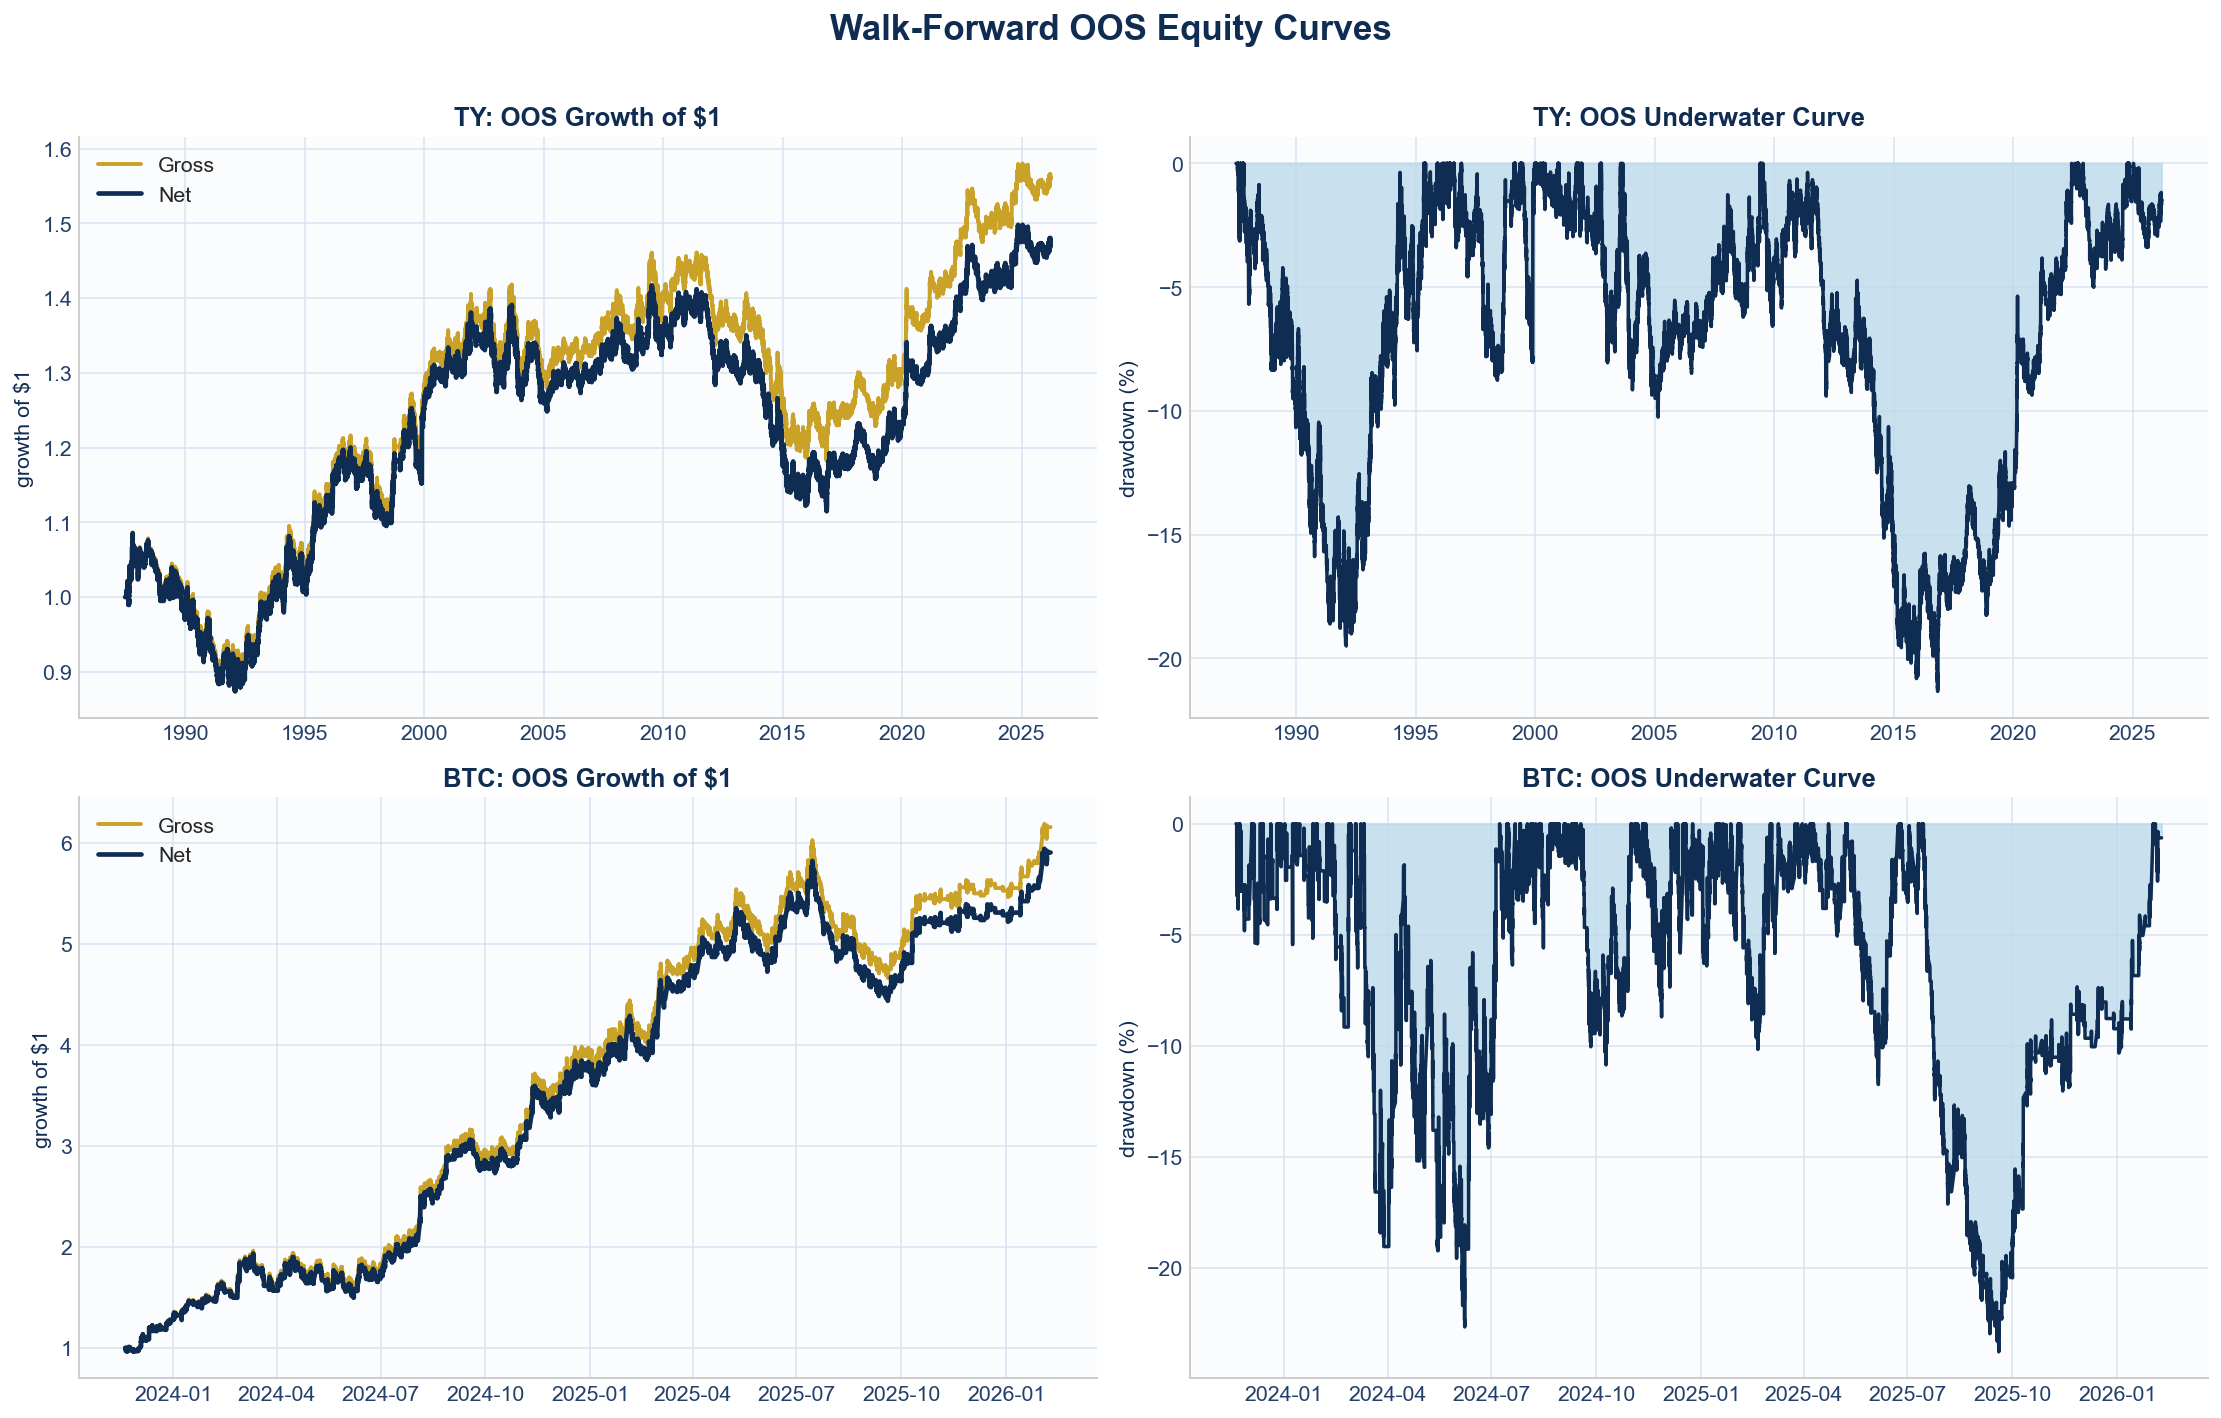

In [7]:
def add_drawdown(df: pd.DataFrame, equity_col: str) -> pd.DataFrame:
    out = df.copy()
    out["Peak"] = out[equity_col].cummax()
    out["Underwater"] = out[equity_col] / out["Peak"] - 1.0
    out["GrowthOf1"] = out[equity_col] / out[equity_col].iloc[0]
    return out


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
for row, ticker in enumerate(["TY", "BTC"]):
    oos = add_drawdown(markets[ticker]["oos_returns"], "NetEquity")
    axes[row, 0].plot(oos["DateTime"], oos["GrossEquity"] / oos["GrossEquity"].iloc[0], label="Gross", color=COLUMBIA_GOLD, linewidth=2.0)
    axes[row, 0].plot(oos["DateTime"], oos["NetEquity"] / oos["NetEquity"].iloc[0], label="Net", color=COLUMBIA_DARK, linewidth=2.4)
    axes[row, 0].set_title(f"{ticker}: OOS Growth of $1")
    axes[row, 0].set_ylabel("growth of $1")
    axes[row, 0].legend(frameon=False)

    axes[row, 1].fill_between(oos["DateTime"], oos["Underwater"] * 100, 0, color=COLUMBIA_LIGHT, alpha=0.75)
    axes[row, 1].plot(oos["DateTime"], oos["Underwater"] * 100, color=COLUMBIA_DARK, linewidth=1.8)
    axes[row, 1].set_title(f"{ticker}: OOS Underwater Curve")
    axes[row, 1].set_ylabel("drawdown (%)")

fig.suptitle("Walk-Forward OOS Equity Curves", fontsize=18, fontweight="bold", color=COLUMBIA_DARK, y=1.01)
fig.tight_layout()
plt.show()


## 4. Parameter Stability

These plots show how the selected `L` and `S` values evolved over the quarterly walk-forward periods. This matters because the assignment asked us to keep the quarter-by-quarter optimal parameter table and study the practical stability of the system.


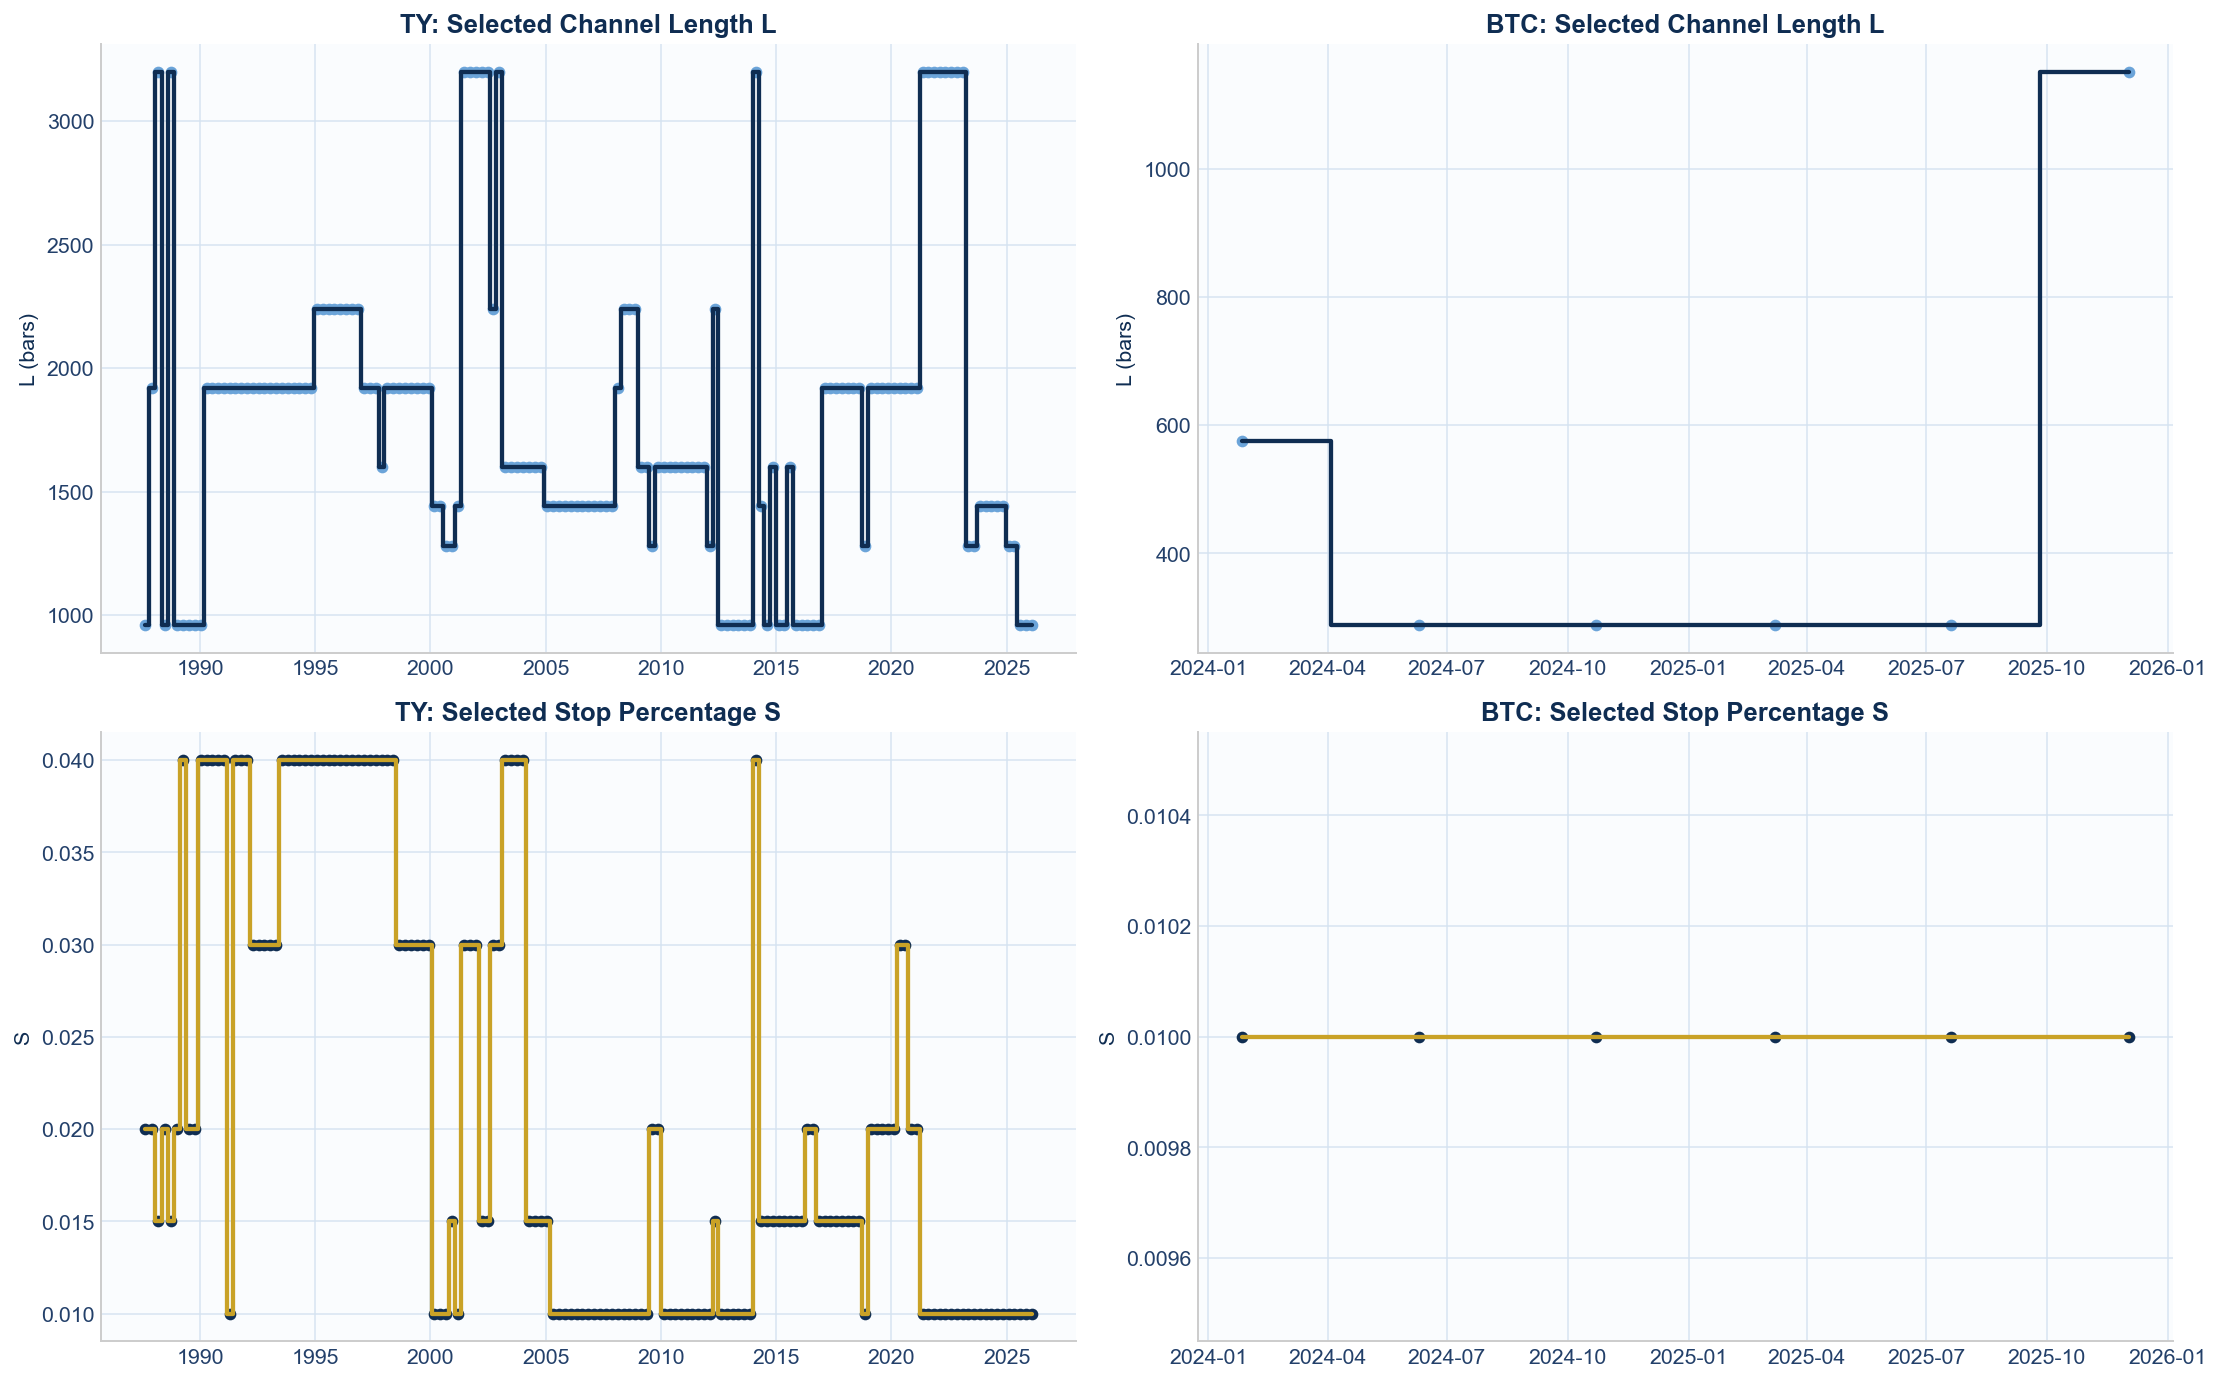

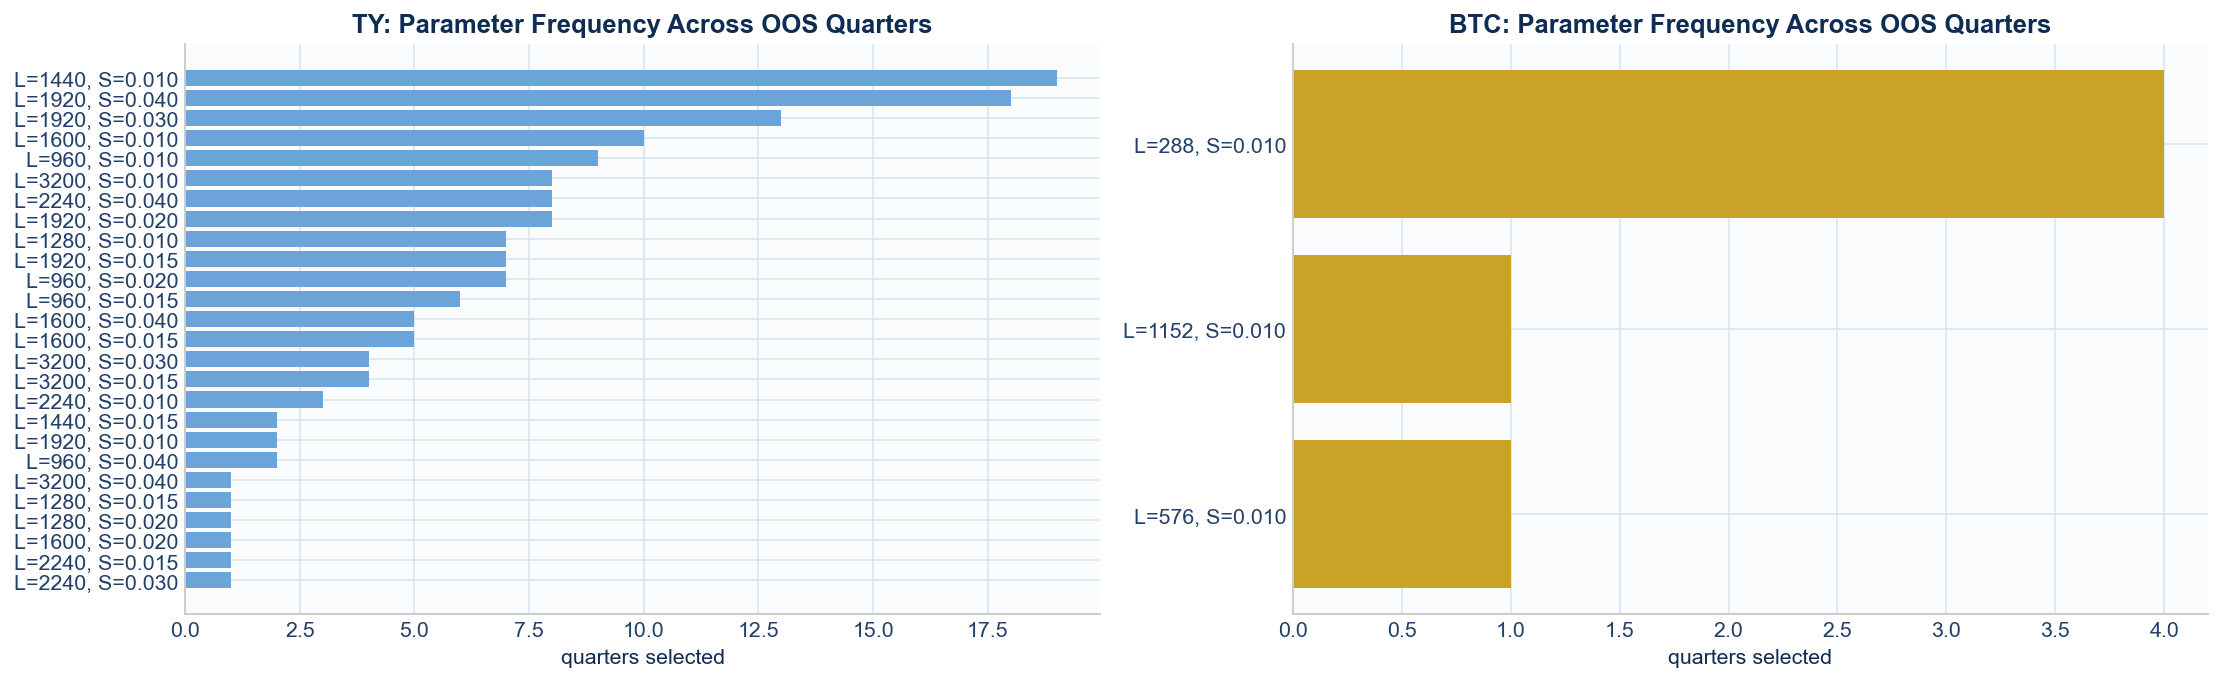

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for col, ticker in enumerate(["TY", "BTC"]):
    periods = markets[ticker]["periods"].copy()
    periods["OOSMid"] = periods["OOSStart"] + (periods["OOSEnd"] - periods["OOSStart"]) / 2
    axes[0, col].step(periods["OOSMid"], periods["L"], where="mid", color=COLUMBIA_DARK, linewidth=2.2)
    axes[0, col].scatter(periods["OOSMid"], periods["L"], color=COLUMBIA_BLUE, s=25)
    axes[0, col].set_title(f"{ticker}: Selected Channel Length L")
    axes[0, col].set_ylabel("L (bars)")

    axes[1, col].step(periods["OOSMid"], periods["S"], where="mid", color=COLUMBIA_GOLD, linewidth=2.2)
    axes[1, col].scatter(periods["OOSMid"], periods["S"], color=COLUMBIA_DARK, s=25)
    axes[1, col].set_title(f"{ticker}: Selected Stop Percentage S")
    axes[1, col].set_ylabel("S")

fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ticker in zip(axes, ["TY", "BTC"]):
    freq = (
        markets[ticker]["periods"]
        .assign(Config=lambda df: "L=" + df["L"].astype(int).astype(str) + ", S=" + df["S"].map(lambda x: f"{x:.3f}"))
        ["Config"]
        .value_counts()
        .sort_values(ascending=True)
    )
    ax.barh(freq.index, freq.values, color=COLUMBIA_BLUE if ticker == "TY" else COLUMBIA_GOLD)
    ax.set_title(f"{ticker}: Parameter Frequency Across OOS Quarters")
    ax.set_xlabel("quarters selected")

fig.tight_layout()
plt.show()


## 5. Cost Sensitivity

The next figure shows how the confirmed OOS results change when we scale transaction costs from `0x` to `2x` the official round-turn slippage.


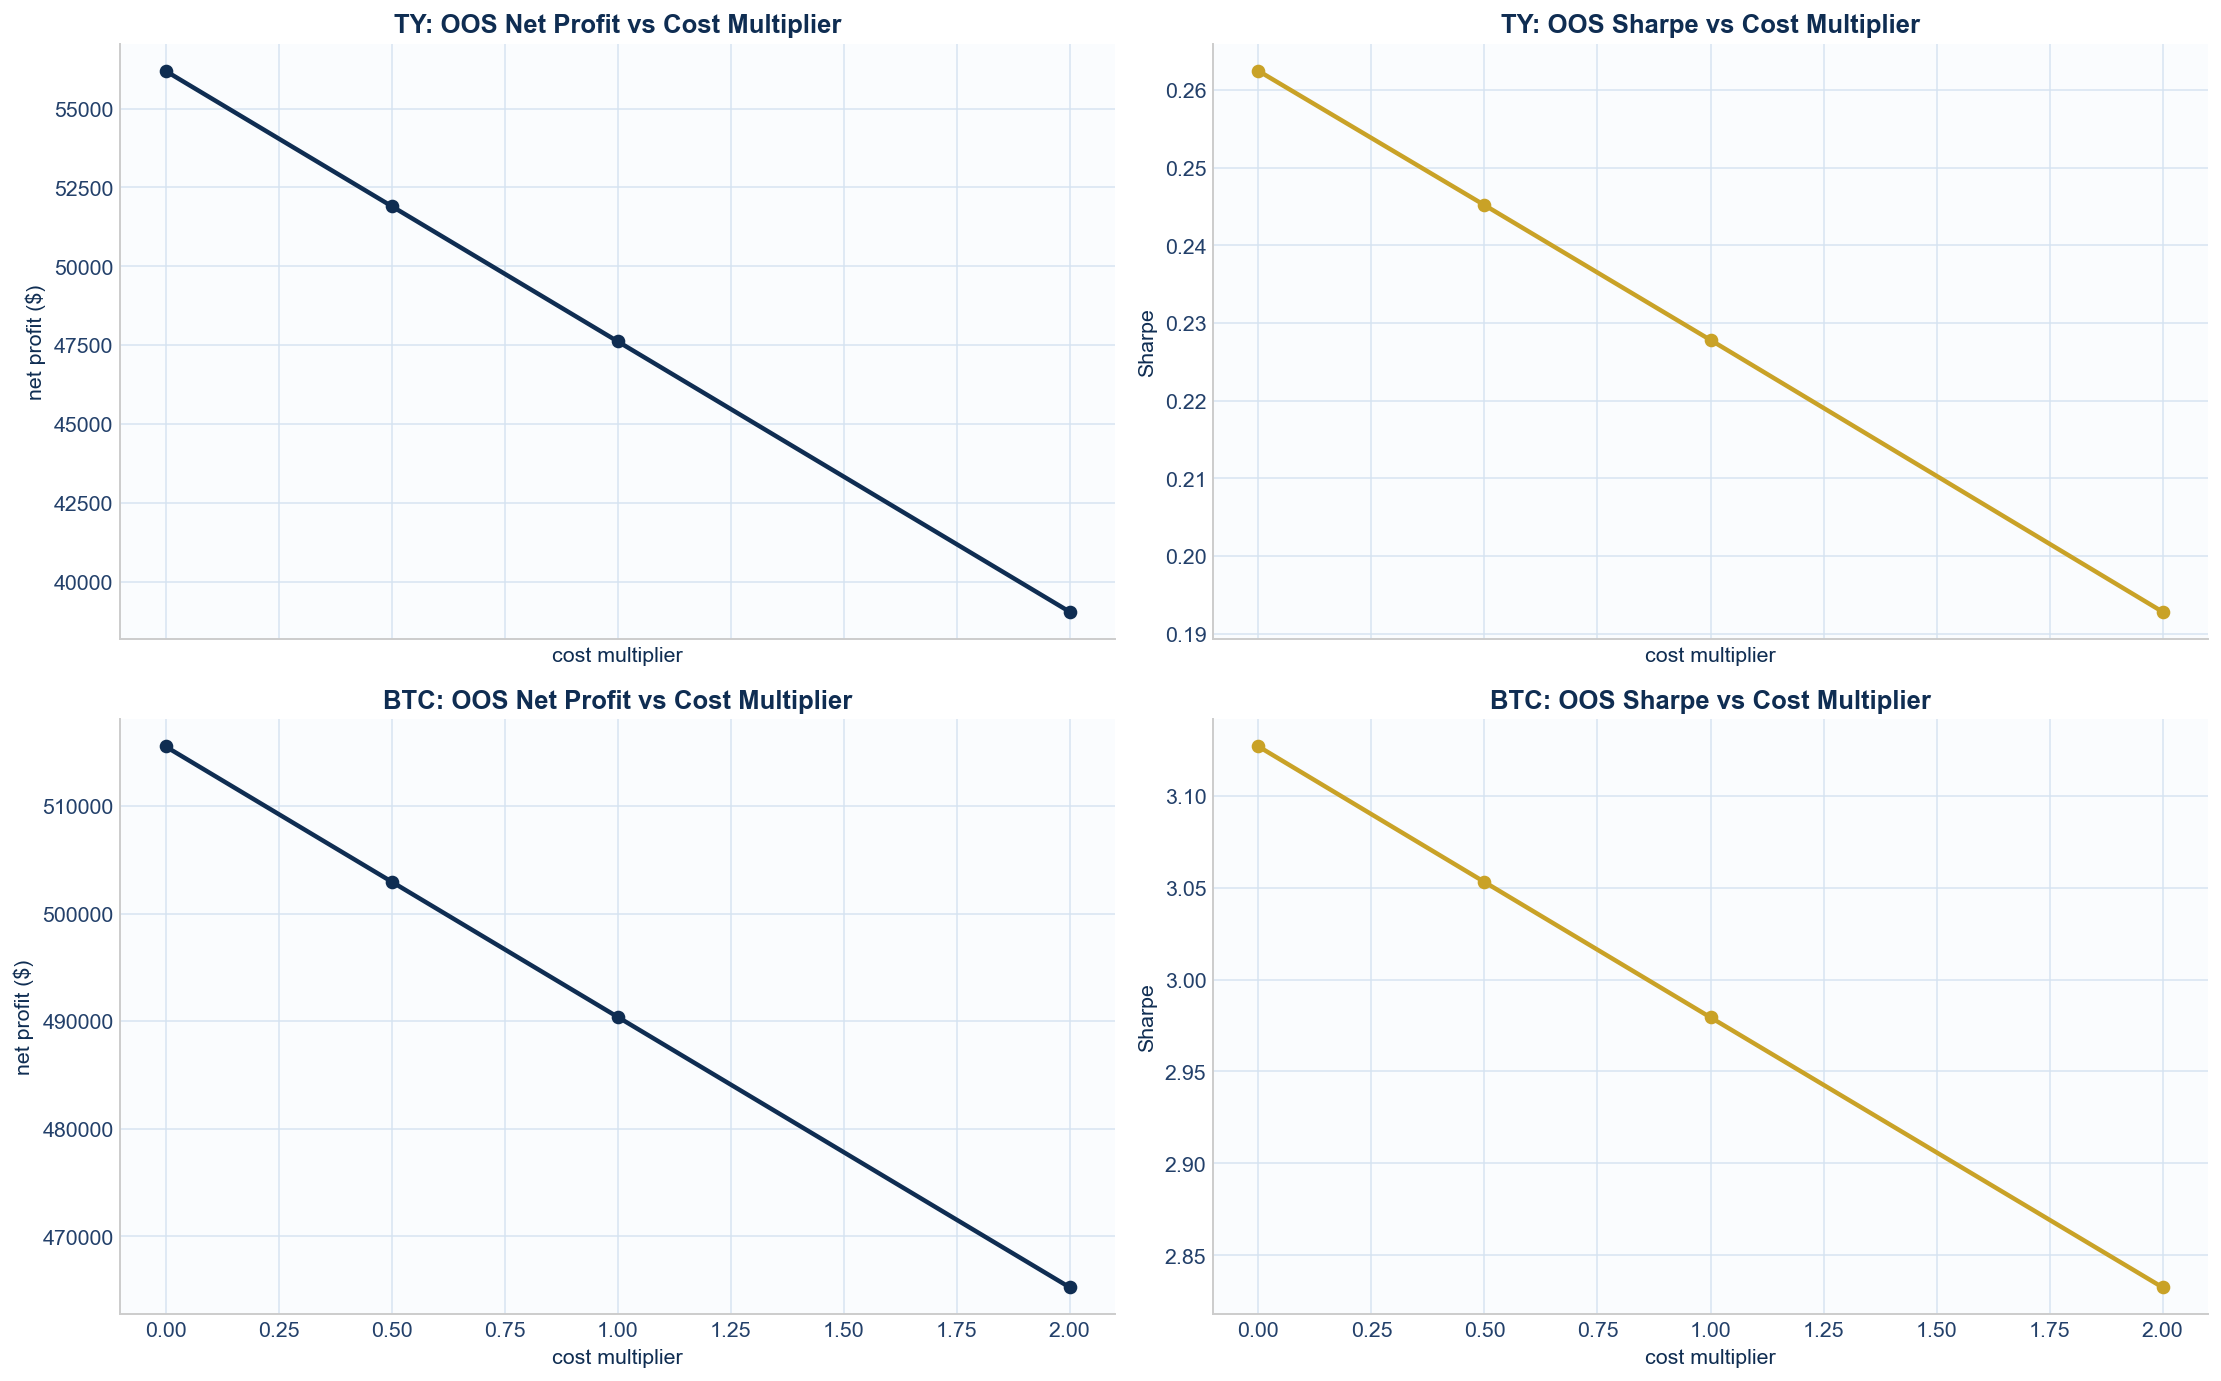

,Ticker,CostMultiplier,Total Profit,Sharpe Ratio,Max Drawdown $,Return on Account
0,TY,0.000000,"$56,195",0.262,"$27,903",2.014
1,TY,0.500000,"$51,907",0.245,"$29,052",1.787
2,TY,1.000000,"$47,619",0.228,"$30,235",1.575
3,TY,2.000000,"$39,042",0.193,"$32,600",1.198
4,BTC,0.000000,"$515,535",3.127,"$136,434",3.779
5,BTC,0.500000,"$502,967",3.053,"$137,421",3.660
6,BTC,1.000000,"$490,398",2.979,"$138,409",3.543
7,BTC,2.000000,"$465,260",2.833,"$140,384",3.314


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for row, ticker in enumerate(["TY", "BTC"]):
    df = cost_sensitivity.loc[cost_sensitivity["Ticker"] == ticker].sort_values("CostMultiplier")
    axes[row, 0].plot(df["CostMultiplier"], df["Total Profit"], color=COLUMBIA_DARK, marker="o", linewidth=2.3)
    axes[row, 0].set_title(f"{ticker}: OOS Net Profit vs Cost Multiplier")
    axes[row, 0].set_ylabel("net profit ($)")
    axes[row, 0].set_xlabel("cost multiplier")

    axes[row, 1].plot(df["CostMultiplier"], df["Sharpe Ratio"], color=COLUMBIA_GOLD, marker="o", linewidth=2.3)
    axes[row, 1].set_title(f"{ticker}: OOS Sharpe vs Cost Multiplier")
    axes[row, 1].set_ylabel("Sharpe")
    axes[row, 1].set_xlabel("cost multiplier")

fig.tight_layout()
plt.show()

display(
    cost_sensitivity[["Ticker", "CostMultiplier", "Total Profit", "Sharpe Ratio", "Max Drawdown $", "Return on Account"]]
    .style.format(
        {
            "Total Profit": money,
            "Sharpe Ratio": ratio,
            "Max Drawdown $": money,
            "Return on Account": ratio,
        }
    )
)


## 6. Benchmark Comparison

To keep the story tight, we compare three lenses:

- `walkforward_oos`: the assignment’s main rolling OOS experiment,
- `full_sample`: one full-period TF benchmark with the modal walk-forward configuration,
- `reference_*`: the Matlab-style fixed-split reference run.


In [10]:
compare = summary.loc[
    summary["RunType"].isin(["walkforward_oos", "full_sample", "reference_out_of_sample", "reference_full"]),
    ["Market", "RunType", "L", "S", "NetProfit", "NetMaxDD", "NetRoA", "TotalCost", "ClosedTrades", "RoundTurnCost"],
].copy()

display(
    compare.sort_values(["Market", "RunType"]).style.format(
        {
            "S": "{:.3f}",
            "NetProfit": money,
            "NetMaxDD": money,
            "NetRoA": ratio,
            "TotalCost": money,
            "ClosedTrades": "{:,.0f}",
            "RoundTurnCost": money,
        }
    )
)


,Market,RunType,L,S,NetProfit,NetMaxDD,NetRoA,TotalCost,ClosedTrades,RoundTurnCost
6,BTC,full_sample,288,0.010,"$1,727,344","$138,409",12.480,"$122,038","4,881",$25
9,BTC,reference_full,576,0.010,"$1,139,310","$99,860",11.409,"$79,688","3,187",$25
8,BTC,reference_out_of_sample,576,0.010,"$421,692","$99,860",4.223,"$22,838",913,$25
5,BTC,walkforward_oos,288,0.010,"$490,398","$138,409",3.543,"$25,138","1,005",$25
1,TY,full_sample,1440,0.010,"$85,135","$15,273",5.574,"$13,391",719,$19
4,TY,reference_full,1280,0.010,"$92,701","$13,650",6.791,"$13,932",748,$19
3,TY,reference_out_of_sample,1280,0.010,"$32,191","$13,650",2.358,"$3,446",185,$19
0,TY,walkforward_oos,1440,0.010,"$47,619","$30,235",1.575,"$8,577",403,$19


In [11]:
final_lines = []
for ticker in ["TY", "BTC"]:
    wf = walkforward.loc[walkforward["Market"] == ticker].iloc[0]
    ref = reference_oos.loc[reference_oos["Market"] == ticker].iloc[0]
    full = fullsample.loc[fullsample["Market"] == ticker].iloc[0]
    if ticker == "TY":
        ineff = "short-horizon MR / mixed behavior, but longer-horizon trend-following recovery"
    else:
        ineff = "mixed short-horizon behavior, with the cleaner TF signal showing up at longer horizons"
    final_lines.append(
        f"- **{ticker}:** the diagnostics point to {ineff}. "
        f"In the confirmed walk-forward run, the system used modal parameters `L={int(wf['L'])}`, `S={wf['S']:.3f}` "
        f"and produced OOS net profit of {money(wf['NetProfit'])}, net max drawdown of {money(wf['NetMaxDD'])}, "
        f"and net RoA of {wf['NetRoA']:.3f}. "
        f"The fixed-split reference OOS run delivered {money(ref['NetProfit'])}, while the full-sample benchmark delivered {money(full['NetProfit'])}."
    )

display(
    Markdown(
        "## 7. Final Takeaways\n"
        + "\n".join(final_lines)
        + "\n\n"
        + "These figures are suitable for the final report because they are drawn from the confirmed C++ backtest outputs, "
        + "use the official TF Data slippage assumptions, and present the assignment’s required diagnostics and walk-forward performance in one place."
    )
)


## 7. Final Takeaways
- **TY:** the diagnostics point to short-horizon MR / mixed behavior, but longer-horizon trend-following recovery. In the confirmed walk-forward run, the system used modal parameters `L=1440`, `S=0.010` and produced OOS net profit of $47,619, net max drawdown of $30,235, and net RoA of 1.575. The fixed-split reference OOS run delivered $32,191, while the full-sample benchmark delivered $85,135.
- **BTC:** the diagnostics point to mixed short-horizon behavior, with the cleaner TF signal showing up at longer horizons. In the confirmed walk-forward run, the system used modal parameters `L=288`, `S=0.010` and produced OOS net profit of $490,398, net max drawdown of $138,409, and net RoA of 3.543. The fixed-split reference OOS run delivered $421,692, while the full-sample benchmark delivered $1,727,344.

These figures are suitable for the final report because they are drawn from the confirmed C++ backtest outputs, use the official TF Data slippage assumptions, and present the assignment’s required diagnostics and walk-forward performance in one place.